# Experiment Results

## Experiment Picker

Use the widget below to select and load experiments from `data/`.

### Mode Selection
- **Single Experiment** (default): Select one experiment and automatically load all its configurations. Uses a radio button for experiment selection.
- **Multiple Experiments**: Select multiple experiments and customize which configurations to load for each. Uses checkboxes for selection.

### Configuration Handling
- If an experiment contains configuration subfolders (for example, `data/exp/<cfg>/001`), it is treated as a multi-config experiment, and configuration pickers are shown.
- If the experiment has `001` directly under `data/exp/001`, it is treated as a single-run experiment, and no configuration picker is shown.

### Load Experiment(s)
- After selecting experiments and configurations, click Load experiment(s).
- The data is loaded automatically from `block.csv`, then you can click the save data button if you want to cache the loaded data locally.

### Save Data and Fast Load
- After the data is loaded (as DataFrames), a `save data` button appears. Clicking it saves the loaded data locally.
- Data saved this way can later be loaded directly using the Fast load option.

### Troubleshooting
- If the widgets do not appear, or importing `plothelpers` raises an error, install the widget dependency with:
    ```bash
    pip install ipywidgets
    ```
- If you did not use `run-experiment.sh` to produce the data, make sure it is stored in this format: `data/experiment_<exp_name>/<consensus>_<number_of_agents>/<run>/<robot_ID>`.


In [1]:
# Run the Experiment Picker
from pathlib import Path
import importlib
import ipywidgets as widgets
from IPython.display import display
import plothelpers as ph
ph = importlib.reload(ph)
ph.SEPARATE_EXPERIMENT_DATA = bool(globals().get('separate_experiment_data_enabled', getattr(ph, 'SEPARATE_EXPERIMENT_DATA', True)))

# create and show the picker (data folder is relative to this notebook)
DATA_DIR = Path('data')
picker = ph.create_and_show_picker(DATA_DIR)

# Load data immediately after experiment selection
original_callback = picker.load_button._click_handlers.callbacks[0] if picker.load_button._click_handlers.callbacks else None

def enhanced_load_callback(btn):
    if original_callback:
        original_callback(btn)

    if picker.last_loaded:
        globals()['get_selections'] = ph.create_csv_picker_for_loaded_paths(picker, DATA_DIR)

# Replace the callback
picker.load_button._click_handlers.callbacks = []
picker.load_button.on_click(enhanced_load_callback)

VBox()

Button(description='save data', layout=Layout(display='none'), style=ButtonStyle())

Output()

> **Make sure the**
> ```bash
> ✓ Data loaded successfully!
> ```
> **before continuing!**

## Plot Options

|Option|Default| What it does|
|---|---|---|
|Show outliers|OFF|Depicts outliers with ★ in the boxplot|
|Show data points|OFF|Depicts all individual data points in the boxplot|
|seperate experiments|OFF|Same consensus from different experiment are shown in the same boxplot next to each other. When OFF they are aggregated|
|Plot Autosave|ON|Saves plots to plots/expeiment_name/plot_name.png|

In [2]:
# Toggle whether outliers are shown in boxplots
import importlib
import ipywidgets as widgets
from IPython.display import display
import plothelpers as ph
ph = importlib.reload(ph)

out = widgets.Output()
show_outliers_toggle = widgets.ToggleButton(
    value=bool(globals().get('show_outliers_enabled', getattr(ph, 'SHOW_OUTLIERS', False))),
    description=f"Show outliers: {'ON' if bool(globals().get('show_outliers_enabled', getattr(ph, 'SHOW_OUTLIERS', False))) else 'OFF'}",
    icon='star',
)

data_points_out = widgets.Output()
show_data_points_toggle = widgets.ToggleButton(
    value=bool(globals().get('show_data_points_enabled', getattr(ph, 'SHOW_DATA_POINTS', False))),
    description=f"Show data points: {'ON' if bool(globals().get('show_data_points_enabled', getattr(ph, 'SHOW_DATA_POINTS', False))) else 'OFF'}",
    icon='dot-circle',
)

separate_experiment_out = widgets.Output()
separate_experiment_toggle = widgets.ToggleButton(
    value=getattr(ph, 'SEPARATE_EXPERIMENT_DATA', True),
    description=f"Separate experiment data: {'ON' if getattr(ph, 'SEPARATE_EXPERIMENT_DATA', True) else 'OFF'}",
    button_style='success' if getattr(ph, 'SEPARATE_EXPERIMENT_DATA', True) else '',
    tooltip='Keep experiments separate instead of combining matching consensus values',
    icon='sitemap',
)

autosave_out = widgets.Output()
autosave_default = bool(globals().get('autosave_enabled', True))
autosave_toggle = widgets.ToggleButton(
    value=autosave_default,
    description=f"Plot autosave: {'ON' if autosave_default else 'OFF'}",
    button_style='success' if autosave_default else '',
    tooltip='Enable/disable automatic plot saving',
    icon='save',
)

show_outliers_enabled = bool(show_outliers_toggle.value)
show_data_points_enabled = bool(show_data_points_toggle.value)
separate_experiment_data_enabled = bool(separate_experiment_toggle.value)
autosave_enabled = bool(autosave_toggle.value)
ph.SHOW_OUTLIERS = show_outliers_enabled
ph.SHOW_DATA_POINTS = show_data_points_enabled
ph.SEPARATE_EXPERIMENT_DATA = separate_experiment_data_enabled
ph.configure_plot_saving(enabled=autosave_enabled, plot_dir='plots', dpi=300)


def _sync_plothelper_settings():
    ph.SHOW_OUTLIERS = bool(show_outliers_toggle.value)
    ph.SHOW_DATA_POINTS = bool(show_data_points_toggle.value)
    ph.SEPARATE_EXPERIMENT_DATA = bool(separate_experiment_toggle.value)
    globals()['show_outliers_enabled'] = bool(show_outliers_toggle.value)
    globals()['show_data_points_enabled'] = bool(show_data_points_toggle.value)
    globals()['separate_experiment_data_enabled'] = bool(separate_experiment_toggle.value)
    globals()['autosave_enabled'] = bool(autosave_toggle.value)
    ph.configure_plot_saving(enabled=bool(autosave_toggle.value), plot_dir='plots', dpi=300)


def _on_toggle(change):
    enabled = bool(change['new'])
    ph.SHOW_OUTLIERS = enabled
    globals()['show_outliers_enabled'] = enabled
    show_outliers_toggle.description = f"Show outliers: {'ON' if enabled else 'OFF'}"
    show_outliers_toggle.button_style = 'success' if enabled else ''
    with out:
        out.clear_output()
        print('ph.SHOW_OUTLIERS =', enabled)



def _on_data_points_toggle(change):
    enabled = bool(change['new'])
    ph.SHOW_DATA_POINTS = enabled
    globals()['show_data_points_enabled'] = enabled
    show_data_points_toggle.description = f"Show data points: {'ON' if enabled else 'OFF'}"
    show_data_points_toggle.button_style = 'success' if enabled else ''
    with data_points_out:
        data_points_out.clear_output()
        print('ph.SHOW_DATA_POINTS =', enabled)



def _on_separate_experiment_toggle(change):
    enabled = bool(change['new'])
    ph.SEPARATE_EXPERIMENT_DATA = enabled
    globals()['separate_experiment_data_enabled'] = enabled
    separate_experiment_toggle.description = f"Separate experiment data: {'ON' if enabled else 'OFF'}"
    separate_experiment_toggle.button_style = 'success' if enabled else ''
    with separate_experiment_out:
        separate_experiment_out.clear_output()
        print('ph.SEPARATE_EXPERIMENT_DATA =', enabled)



def _on_autosave_toggle(change):
    enabled = bool(change['new'])
    globals()['autosave_enabled'] = enabled
    with autosave_out:
        autosave_out.clear_output()
        ph.configure_plot_saving(enabled=enabled, plot_dir='plots', dpi=300)

    autosave_toggle.description = f"Plot autosave: {'ON' if enabled else 'OFF'}"
    autosave_toggle.button_style = 'success' if enabled else ''


show_outliers_toggle.observe(_on_toggle, names='value')
show_data_points_toggle.observe(_on_data_points_toggle, names='value')
separate_experiment_toggle.observe(_on_separate_experiment_toggle, names='value')
autosave_toggle.observe(_on_autosave_toggle, names='value')
display(
    widgets.HBox([
        show_outliers_toggle,
        show_data_points_toggle,
        separate_experiment_toggle,
        autosave_toggle,
    ]),
    widgets.VBox([out, data_points_out, separate_experiment_out, autosave_out])
)

Automatic plot saving enabled. Base directory: plots


## Data Previews
Use this section to inspect the loaded DataFrames.

### Agents (CSV)

In [ ]:
# Run the data preview
# Preview helper: choose experiment & see a combined preview (no csv_basename key anymore)
ph.show_loaded_preview()


### Observations (JSON)
Use this section to inspect the loaded block observation DataFrames grouped by block hash.

In [ ]:
# Run the block observation preview
ph.show_loaded_blocks_preview()

### Production Summary
Shows the number of blocks produced by each robot (from monitor.log files).

In [ ]:
# Run the block production summary
# Show block production counts from monitor.log files
ph.show_block_production_summary()

# You can also access the data using helper functions:
# ph.get_block_production_count(experiment, rep, robot)
# Examples:
#   ph.get_block_production_count('ProofOfWork_5', '1', 2)  # Get count for robot 2 in rep 1
#   ph.get_block_production_count('ProofOfWork_5', '1')     # Get all robots in rep 1
#   ph.get_block_production_count('ProofOfWork_5')          # Get all reps

# Or access the raw dict directly:
# block_production_counts[experiment][rep][robot] -> count

## Total Produced Blocks (TPB)
The total number of blocks produced by all agents during a simulation run, regardless of whether they are included in the main chain or discarded. This metric reflects the overall block production activity and indicates the level of contention and redundant work within the network.

In [ ]:
# Run total produced blocks boxplot
ph.show_total_produced_blocks_boxplot()


Saved plot to plots/combined/total_produced_blocks_boxplot_combined.png


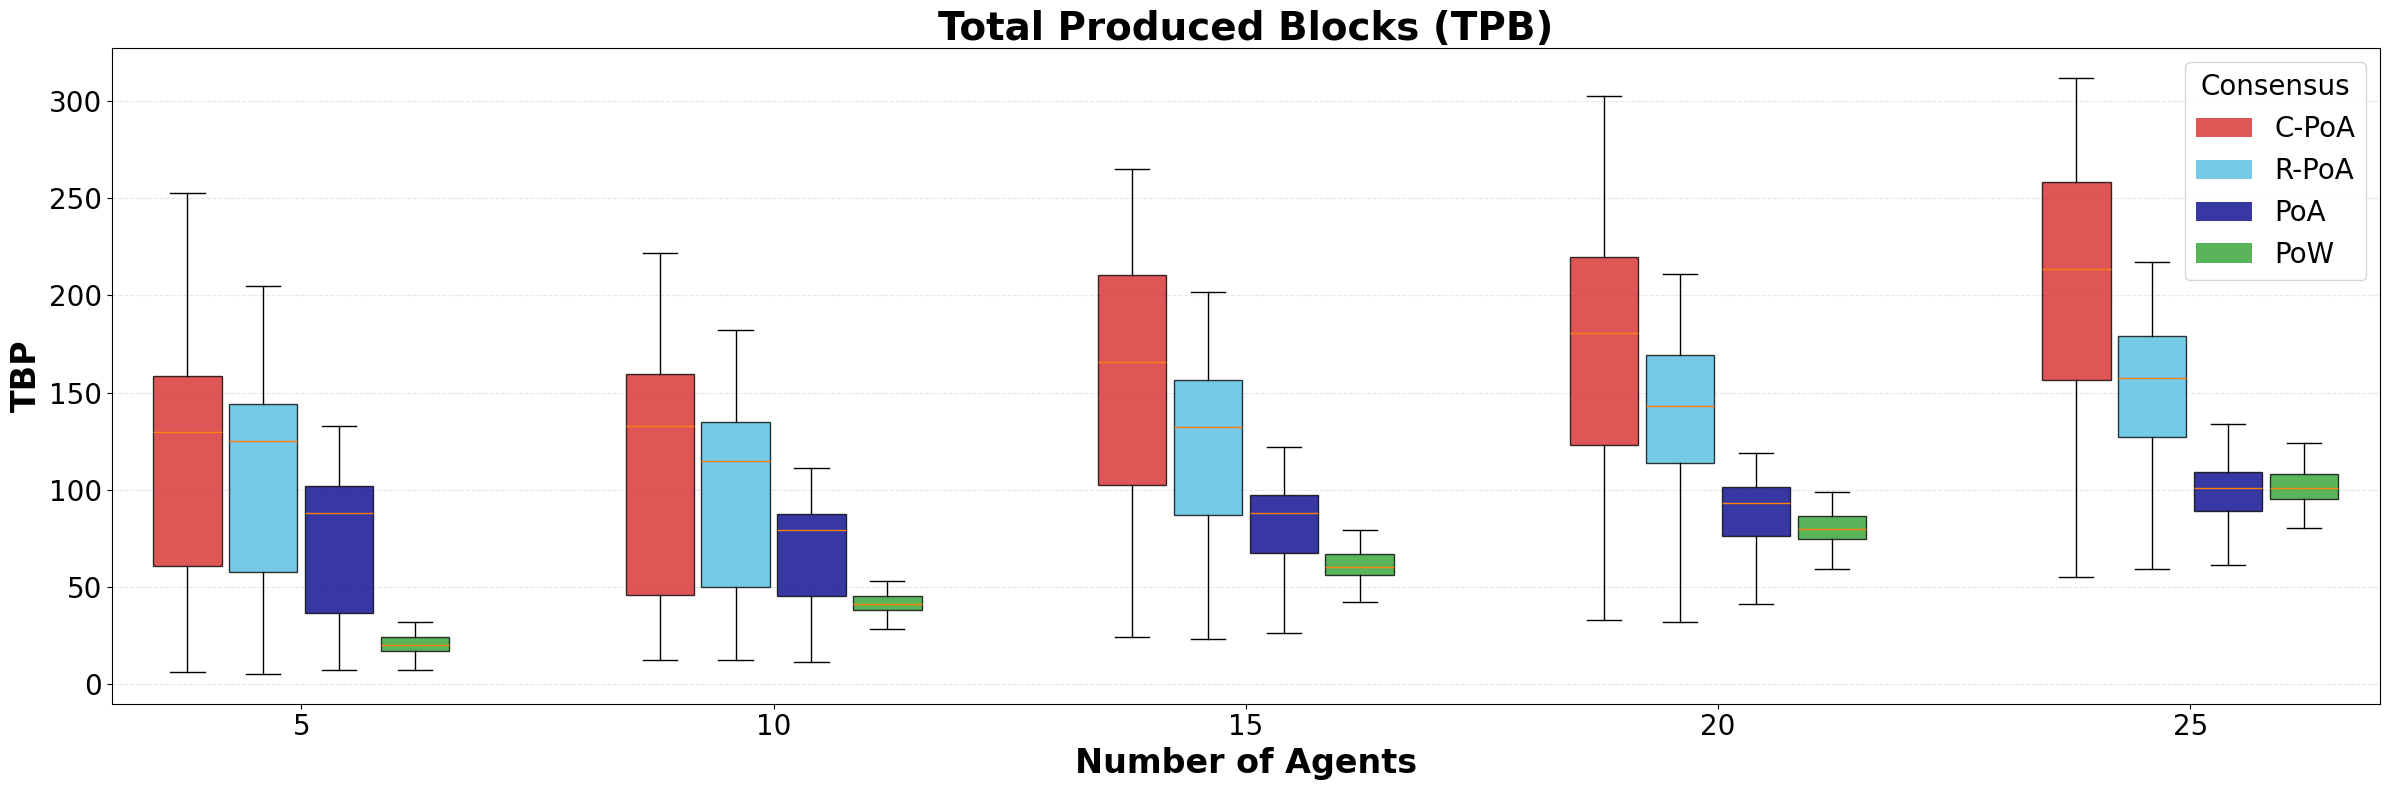


Summary Statistics (TBP):
                      count        mean  median        std  min  max
consensus num_agents                                                
C-PoA     5             120  116.591667   129.5  63.288388    6  253
          10            120  115.166667   133.0  62.846663   12  222
          15            120  154.683333   165.5  69.238473   24  265
          20            120  170.558333   180.5  71.869372   33  303
          25            120  198.616667   213.5  76.711638   55  312
PoA       5             120   75.700000    88.0  34.963030    7  133
          10            120   69.633333    79.0  26.205694   11  111
          15            120   80.958333    88.0  22.039078   26  122
          20            120   87.225000    93.0  20.171309   41  119
          25            120   97.058333   101.0  17.116652   58  134
PoW       5             120   20.800000    20.0   4.863861    7   35
          10            120   41.300000    41.0   6.193789   26   61
       

In [3]:
# Run the total produced blocks overview, all consensus protocols combined into one boxplot per agent count
ph.show_total_produced_blocks_boxplot_combined()

## Block Reception Delays (BRD)
The time required for a block to propagate through the network from its creation until it is received by other nodes, reflecting how quickly information can spread across the system.
> not a good metric better look at BI, AE or BPD

### Overview

In [ ]:
# Run BRD mean overview
ph.show_reception_mean_overview()


### Detailed

In [ ]:
# Run the block reception distribution
# Block reception distribution with separated bins
ph.show_reception_bins()

## Block Interval (BI)
The time difference between the creation of consecutive blocks on the main chain, reflecting the rate at which confirmed state updates occur within the system.

### Overview

In [ ]:
# Run BI mean overview
ph.show_block_interval_mean_overview()

Saved plot to plots/combined/mean_bi_overview_combined.png


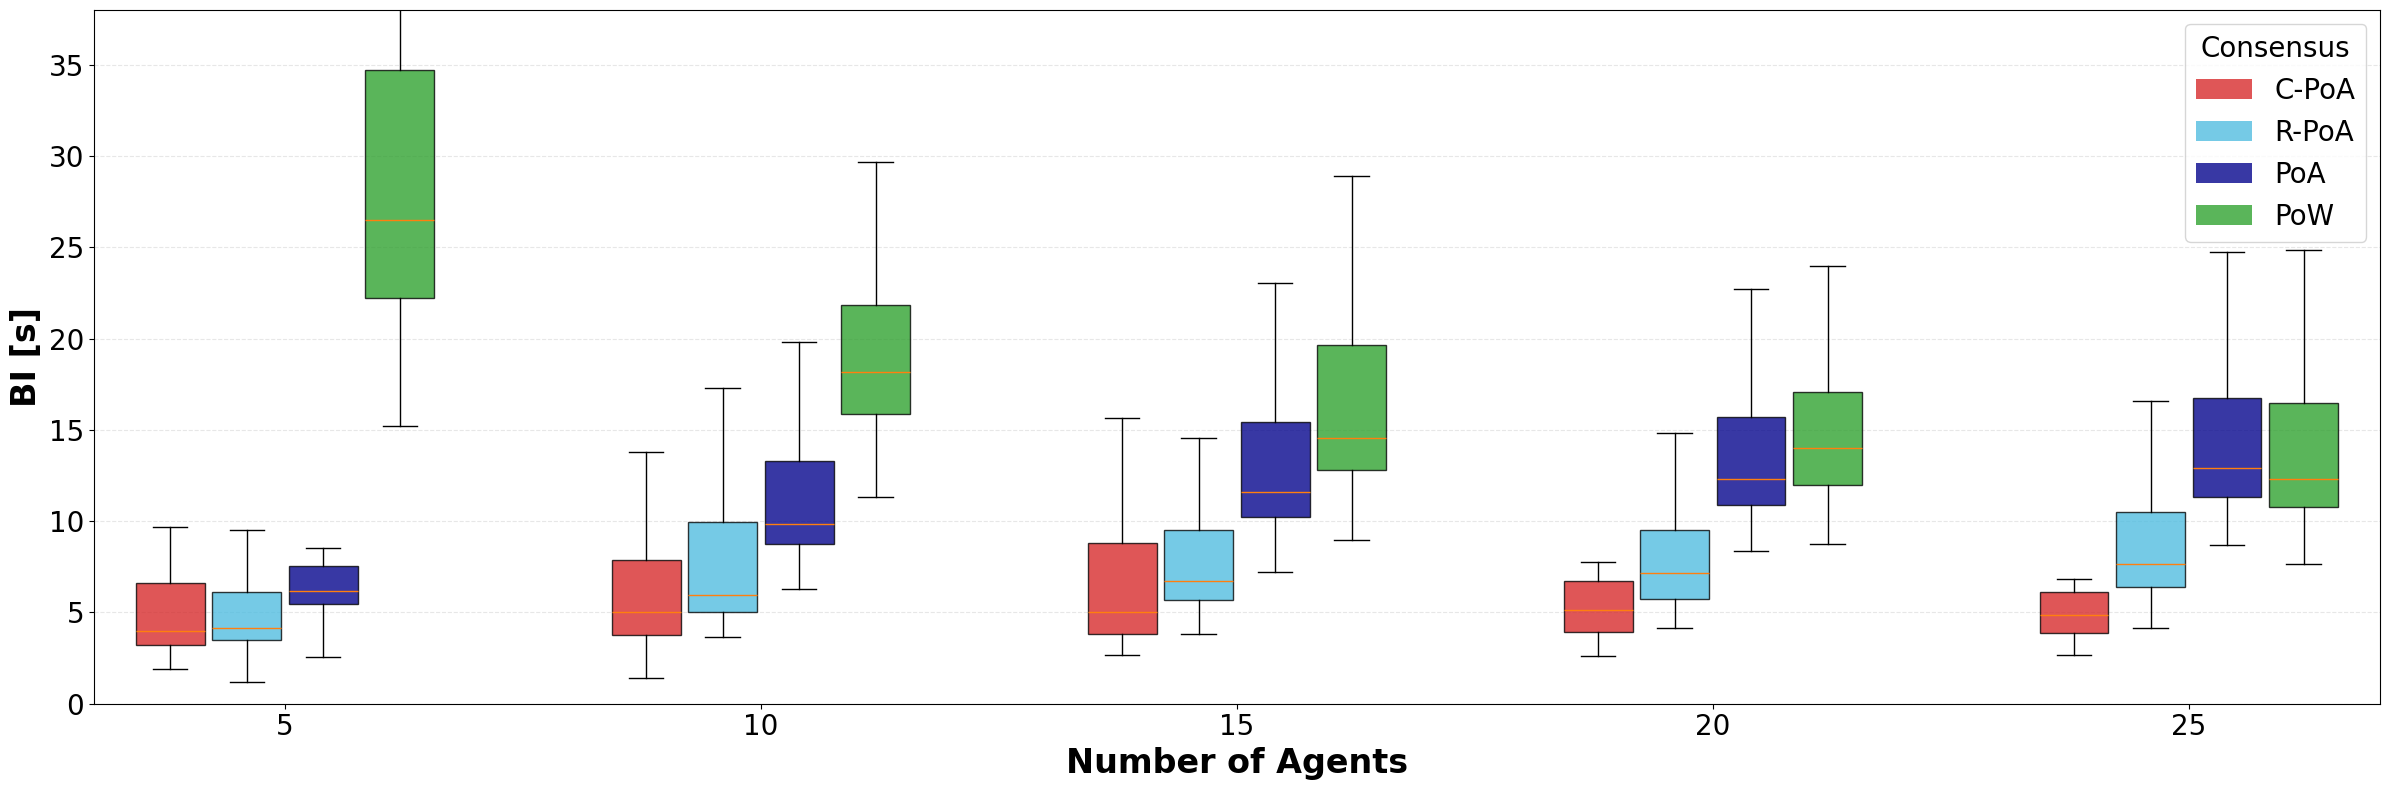


Summary Statistics (BI [s]):
                      count       mean     median        std        min         max
consensus num_agents                                                               
C-PoA     5             120   9.705616   3.976000  19.210900   1.886124  157.050000
          10            120   9.441478   5.018987  11.195541   1.433333   71.700000
          15            120   7.608664   5.030191   6.016989   2.654000   28.523077
          20            120   7.358710   5.129221   5.961895   2.598026   35.963636
          25            120   7.046702   4.881998   5.135991   2.644667   21.753333
PoA       5             120   9.787080   6.158365   8.841351   1.080000   48.060000
          10            120  13.615348   9.870000   8.816215   1.875000   48.450000
          15            120  14.231693  11.601471   6.480288   7.200000   43.066667
          20            120  14.685369  12.320817   5.664653   8.380851   29.330769
          25            120  14.487144  12.915

In [4]:
# Run the BI overview, all consensus protocols combined into one boxplot per agent count
ph.show_block_interval_mean_overview_combined()

### Detailed

In [ ]:
# Run the block interval distribution
# Block Interval (BI) distribution with separated bins
ph.show_block_interval_bins()

## Degree of Decentralization (D)
Let $b_i$ be the number of main-chain blocks produced by node $i$.
we can measure the **Gini-coefficent** of the mainchain block production as follow:

$$
G = \frac{\sum_{i=1}^N \sum_{j=1}^N |b_i - b_j|}{2N \sum_{i=1}^N b_i}
$$

Interpretation:
- $( G = 0 )$: perfectly decentralized (democratic) production everynode produce the same amount of main-chain blocks.
- $( G \to 1 )$: fully centralized (tyranic) a single node produces all the mainchain blocks

that would give us how centralised the block production is so to get our Degree of Decentralization we just use the inverse:

$$
D = 1-G
$$

### Overview

In [ ]:
# Run Degree of Decentralization main-chain overview
ph.show_bpa_gini_main_chain_boxplot()

Saved plot to plots/combined/degree_of_decentralization_main_chain_boxplot_combined.png


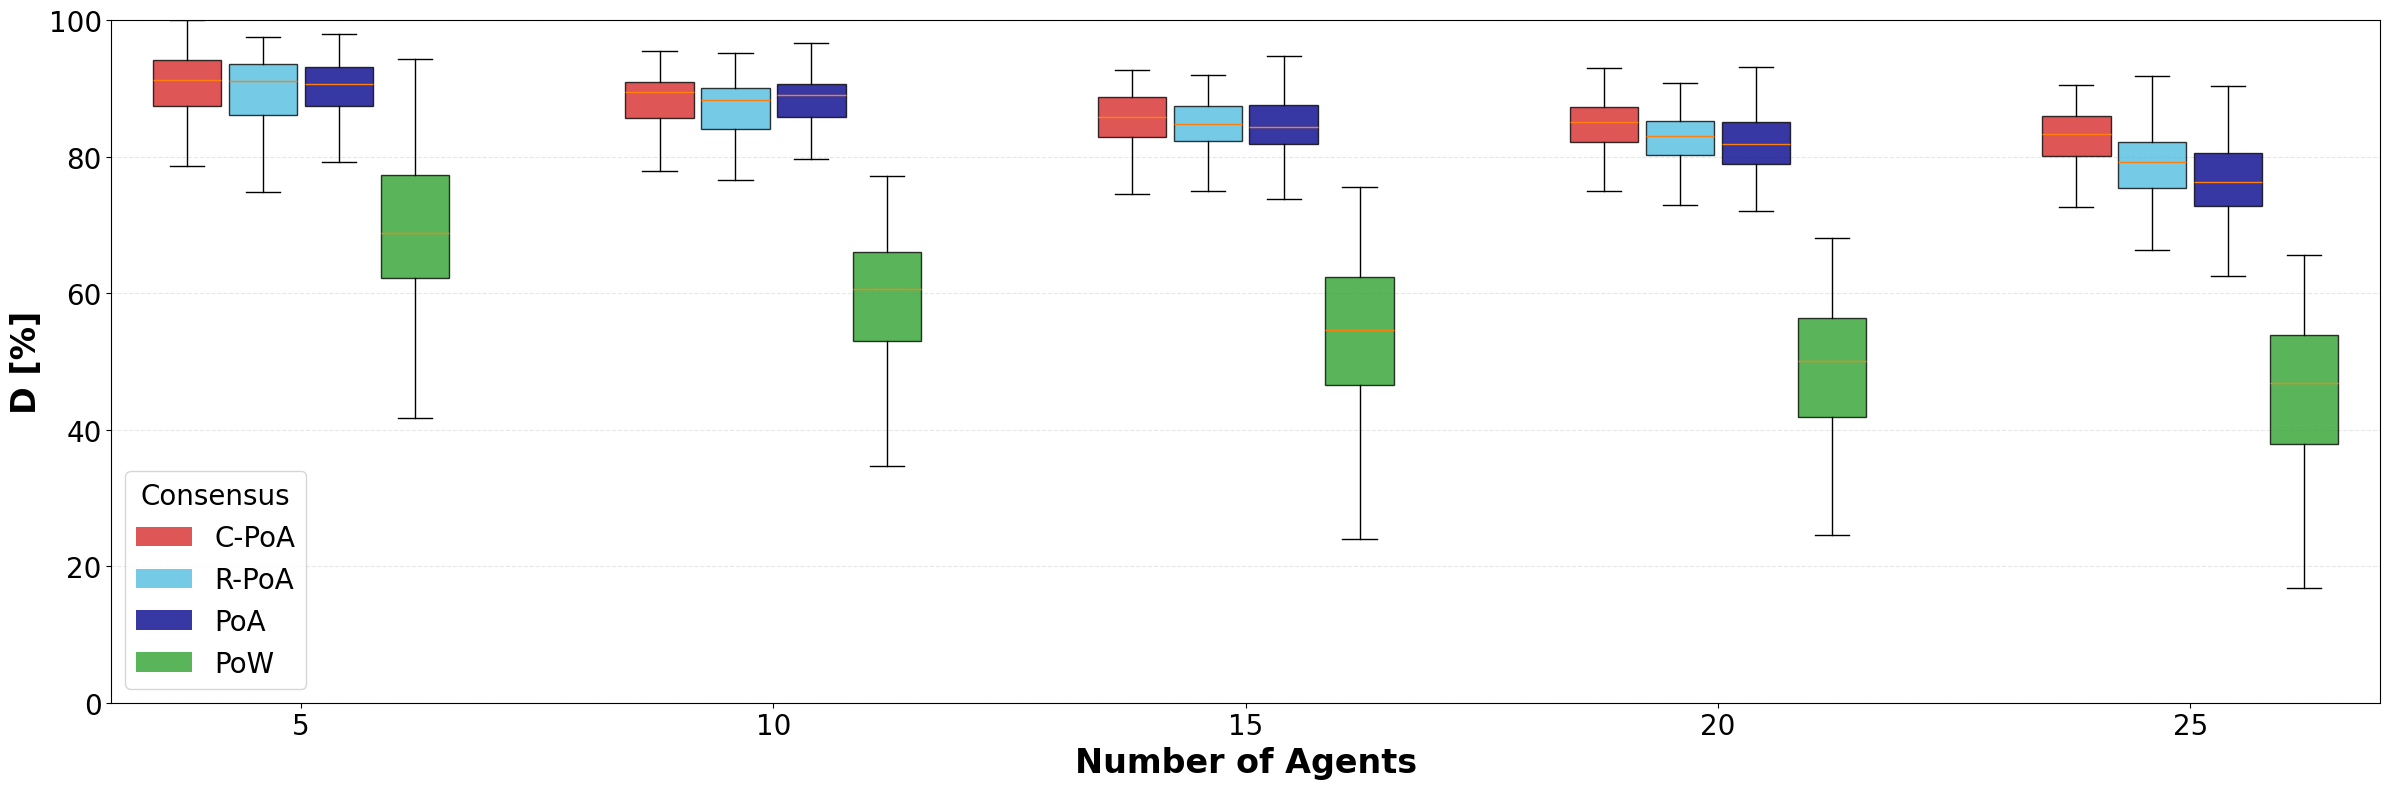


Summary Statistics (D [%]):
                      count       mean     median        std        min         max
consensus num_agents                                                               
C-PoA     5             120  89.652495  91.206061   6.257430  68.750000  100.000000
          10            120  86.494857  89.386447   8.482487  37.500000  100.000000
          15            120  84.825251  85.849421   5.772517  60.185185   92.743764
          20            120  84.067581  85.115294   6.003315  43.750000   93.000000
          25            120  82.437052  83.323810   4.837524  62.500000   90.500000
PoA       5             120  89.338089  90.682272   6.366664  50.000000   97.931034
          10            120  87.460807  88.985879   6.019034  50.000000  100.000000
          15            120  84.025030  84.313725   4.477191  68.333333   94.761905
          20            120  81.587819  81.857143   5.518020  67.434211   94.485294
          25            120  76.445006  76.2424

In [5]:
# Run the Degree of Decentralization overview, all consensus protocols combined into one boxplot per agent count
ph.show_bpa_gini_main_chain_boxplot_combined()

### Detailed (BPA)
Shows the percentage of blocks produced by each agent, split between main-chain blocks (blue) and off-chain blocks (red).

In [ ]:
# Run block production by agent
# Block production by robot
ph.show_block_production_by_robot()

##  Agreement efficency (AE)
Let

- $N$ be the set of all nodes,
- $B$ the set of all produced blocks,
- $A \subseteq B \times N$ is the set of tuples $(n,b)$ where the node $n \in N$ accepted the block $b \in B$ .
- $M \subseteq B$ be the blocks on the mainchain (chain with the higest total difficulty)

a metric for agreement efficency $a$ can be defined as 

$$
a = \frac{|\{(b,n) \in A|b  \in M\}|}{|A|}*100\%
$$

or equivalently

$$
a = \frac{\text{acceptances of } \textbf{main chain blocks} }{\text{total acceptenses}} *100\%
$$

The agreement efficiency metric measures how efficiently the network converges toward the final main chain. It quantifies the fraction of all block acceptance events that correspond to blocks which ultimately become part of the main chain.

In an ideal blockchain without forks, every accepted block belongs to the main chain, resulting in $a = 100\%.$ <br> 
Forks introduce temporary branch blocks that may be accepted by subsets of the network but are later discarded. Acceptance events associated with such fork blocks increase the total number of acceptances without contributing to the numerator, thereby reducing the agreement efficiency.<br>
Consequently:

- values close to $100\%$ indicate fast and efficient fork resolution,
- lower values indicate that nodes spend more effort accepting blocks that do not become part of the final consensus chain,
- long-lasting forks and forks accepted by many nodes reduce the metric more strongly.<br>
**The metric can therefore be interpreted as the percentage of network agreement effort that contributed to the final agreed blockchain state.**

In [ ]:
# Run the agreement overview
ph.show_agreement_boxplot()

In [6]:
# Run the agreement overview, all consensus protocols combined into one boxplot per agent count
ph.show_agreement_boxplot_combined()

Output()

# Block Propagation Delay (BPD)

Measures how fast information spreads through the swarm.
 $T_{80}$ = time until 80% of agents know the information.

In [ ]:
# Run Block Propagation Delay (80% observers)
ph.show_block_propagation_delay()


Saved plot to plots/combined/block_propagation_delay_80pct_combined.png


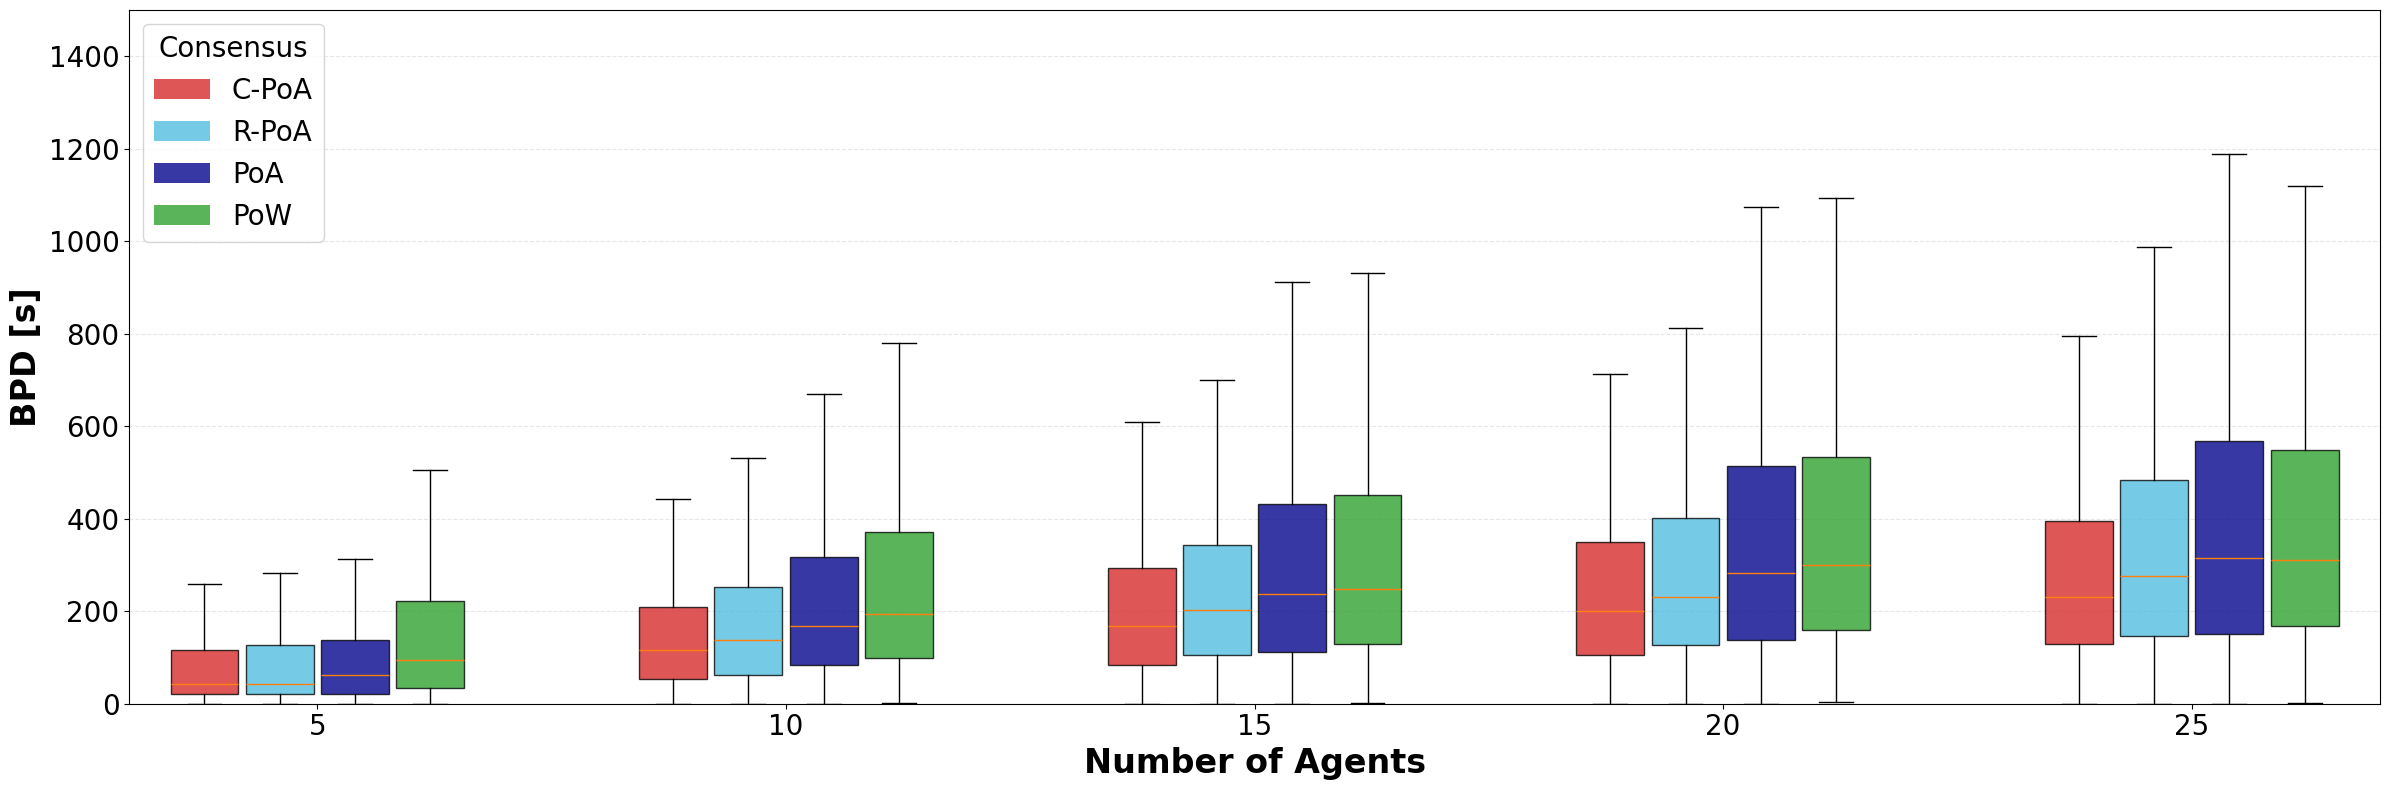


Summary Statistics (BPD [s]):
                      count        mean  median         std  min     max
consensus num_agents                                                    
C-PoA     5           10299  123.773764    42.0  310.367752  0.0  3960.0
          10           7879  191.332149   116.0  302.754031  0.0  3433.0
          15           8548  259.281586   168.0  331.658385  0.0  3784.0
          20           8481  285.226978   200.0  313.097819  0.0  3142.0
          25           8785  336.987934   231.0  390.464766  0.0  3766.0
PoA       5            6269  126.001276    62.0  240.827298  0.0  3335.0
          10           4054  287.003207   168.0  426.618468  0.0  3801.0
          15           3501  373.739217   238.0  455.209327  0.0  3611.0
          20           3308  446.508767   283.5  562.498525  0.0  3822.0
          25           3204  465.639825   315.0  500.474319  0.0  3304.0
PoW       5            1622  247.546239    95.0  457.878380  0.0  3651.0
          10        

In [7]:
# Run the Block Propagation Delay overview, all consensus protocols combined into one boxplot per agent count
ph.show_block_propagation_delay_combined()

# Liveness Overview (BI vs BPD)

Combines both liveness metrics on one pair of axes: Block Interval (BI) on the x-axis, Block Propagation Delay (BPD) on the y-axis. For each consensus protocol, one point per swarm size marks the median (BI, BPD) across that size's runs, labeled with the agent count and connected in increasing agent-count order. The translucent box behind each point spans the interquartile range (Q1-Q3) of BI and BPD, i.e. the box part of the corresponding boxplots.

In [ ]:
# Run the combined liveness plot (BI vs BPD)
ph.show_liveness_scatter()

## Security (S)

The degree of decentralization quantified is not directly associated with the security in blockchains. Therefore, we adopt the Nakamoto coefficient.
The Nakamoto coefficient is defined as the minimum number of entities required to collude for gathering over 51% of the overall mining power to compromise a blockchain system [16]

$$
S = \frac{V}{N}
$$

Where:

- $V$ is the Nakamoto coefficient,
- $N$ is the number of robots involved in the run.

Intuitively, a higher value means the system is more secure because more robots are represented per entity needed to reach the 51% threshold. Compared with the Gini coefficient, this metric is more directly tied to how much of the swarm would need to coordinate to dominate the main-chain difficulty.

In [ ]:
import importlib
import plothelpers as ph
ph = importlib.reload(ph)
ph.SHOW_OUTLIERS = bool(globals().get('show_outliers_enabled', getattr(ph, 'SHOW_OUTLIERS', False)))
ph.SHOW_DATA_POINTS = bool(globals().get('show_data_points_enabled', getattr(ph, 'SHOW_DATA_POINTS', False)))
ph.SEPARATE_EXPERIMENT_DATA = bool(globals().get('separate_experiment_data_enabled', getattr(ph, 'SEPARATE_EXPERIMENT_DATA', True)))
ph.configure_plot_saving(enabled=bool(globals().get('autosave_enabled', False)), plot_dir='plots', dpi=300)

# Run the security plot
ph.show_security_boxplot()

Saved plot to plots/combined/security_boxplot_combined.png


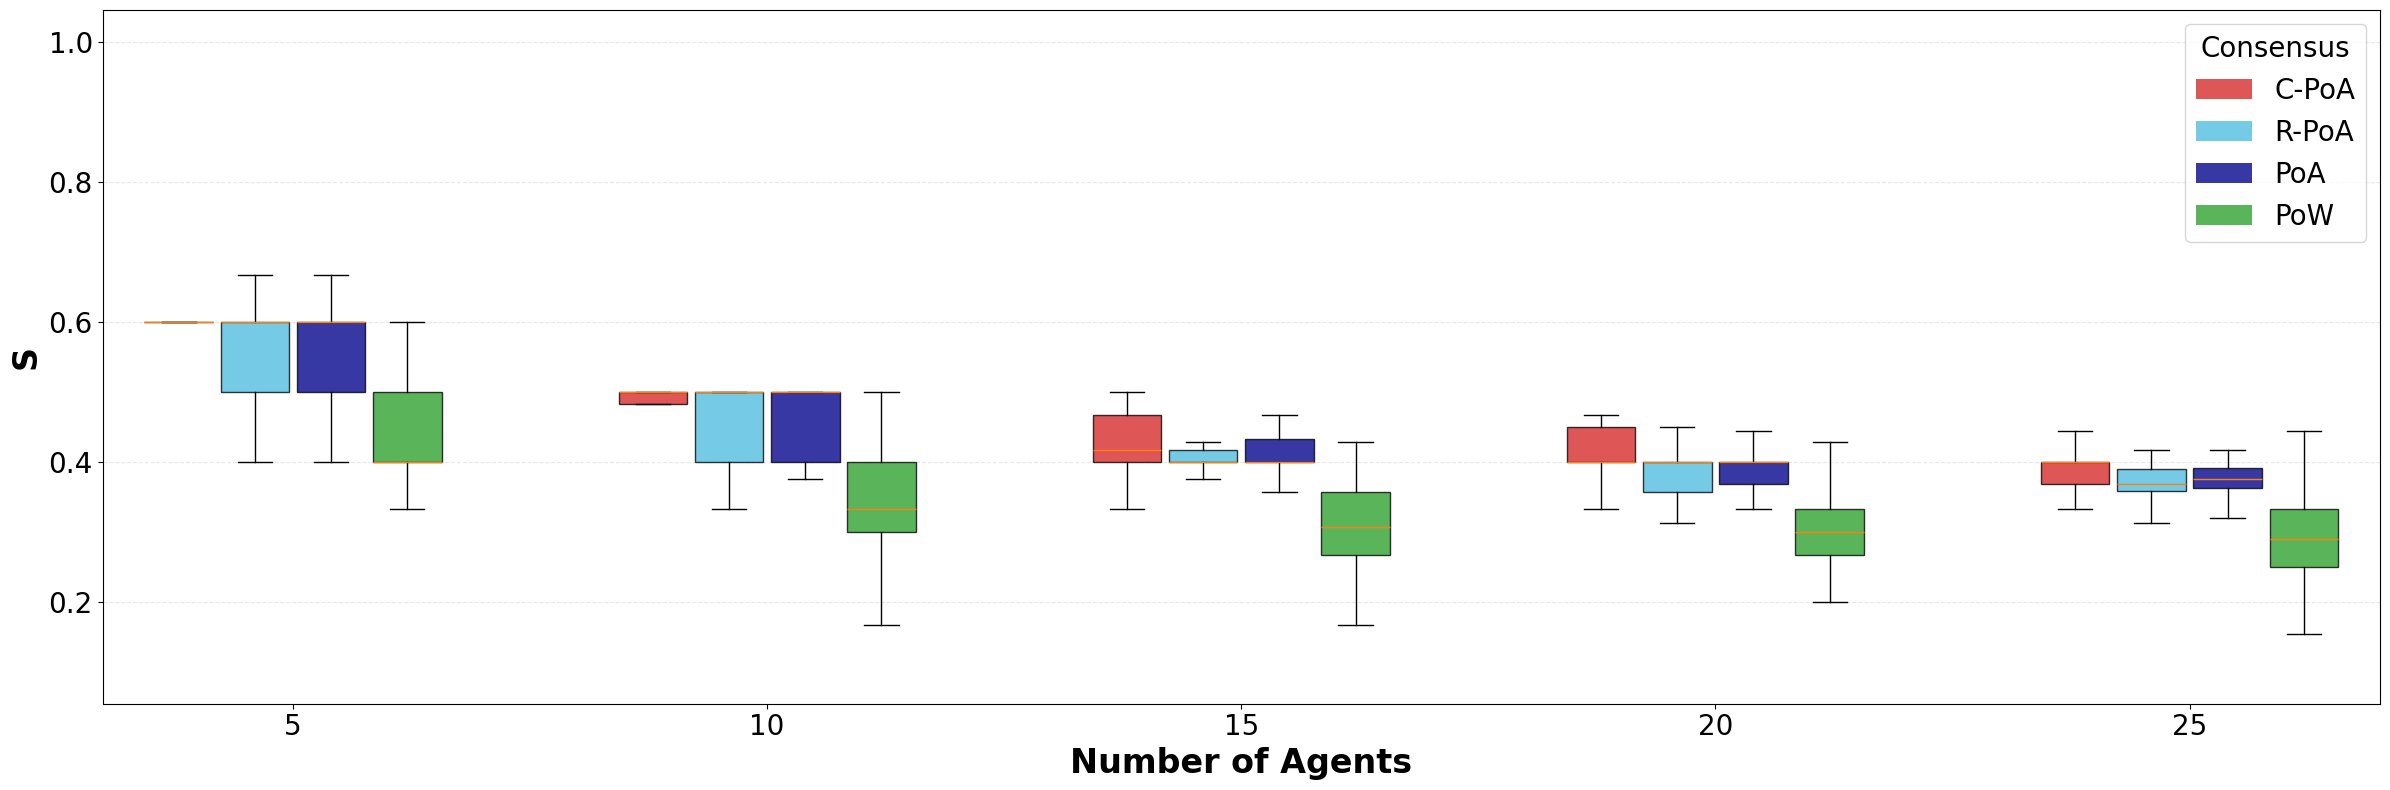


Summary Statistics (S):
                      count      mean    median       std       min       max
consensus num_agents                                                         
C-PoA     5             120  0.576667  0.600000  0.055104  0.400000  0.666667
          10            120  0.474653  0.500000  0.045445  0.333333  0.500000
          15            120  0.432378  0.416667  0.037498  0.333333  0.500000
          20            120  0.412863  0.400000  0.033829  0.285714  0.466667
          25            120  0.392709  0.400000  0.030677  0.300000  0.444444
PoA       5             120  0.557222  0.600000  0.066412  0.400000  0.666667
          10            120  0.465149  0.500000  0.051481  0.375000  0.500000
          15            120  0.408871  0.400000  0.041451  0.333333  0.466667
          20            120  0.392774  0.400000  0.028628  0.333333  0.473684
          25            120  0.375434  0.375000  0.021155  0.320000  0.416667
PoW       5             120  0.434722  

In [8]:
# Run the Security overview, all consensus protocols combined into one boxplot per agent count
ph.show_security_boxplot_combined()

## Speeds

The plot below reads each agent's `monitor.log` file and extracts the first line that contains `speed: <number>`.
If a robot log does not contain a speed line, the loader emits a warning and skips that robot.

In [ ]:
import importlib
import plothelpers as ph
ph = importlib.reload(ph)
ph.SHOW_OUTLIERS = bool(globals().get('show_outliers_enabled', getattr(ph, 'SHOW_OUTLIERS', False)))
ph.SHOW_DATA_POINTS = bool(globals().get('show_data_points_enabled', getattr(ph, 'SHOW_DATA_POINTS', False)))
ph.SEPARATE_EXPERIMENT_DATA = bool(globals().get('separate_experiment_data_enabled', getattr(ph, 'SEPARATE_EXPERIMENT_DATA', True)))
ph.configure_plot_saving(enabled=bool(globals().get('autosave_enabled', False)), plot_dir='plots', dpi=300)

# Run the agent speed plot
ph.show_agent_speed_boxplot()

In [ ]:
# Run the Agent Speed overview, all consensus protocols combined into one boxplot per agent count
ph.show_agent_speed_boxplot_combined()

## Trap Residence Time (TRT)

Measures how much total swarm time is spent inside the trap zone.

This plot is computed from each robot's `zone.csv` file by pairing `ENTER` and `EXIT` events in the `TIME` and `EVENT` columns, then summing the trapped time across all robots in a run. The result is normalized by `experimentconfig.sh` (`LENGTH`) times the number of agents, so the boxplot shows the average fraction of swarm time spent trapped.

$$
TRT = \frac{\sum_{r=1}^{N} \text{time trapped by robot } r}{N * \text{Experiment duration}} * 100\%
$$

In [ ]:
import importlib
import plothelpers as ph
ph = importlib.reload(ph)
ph.SHOW_OUTLIERS = bool(globals().get('show_outliers_enabled', getattr(ph, 'SHOW_OUTLIERS', False)))
ph.SHOW_DATA_POINTS = bool(globals().get('show_data_points_enabled', getattr(ph, 'SHOW_DATA_POINTS', False)))
ph.SEPARATE_EXPERIMENT_DATA = bool(globals().get('separate_experiment_data_enabled', getattr(ph, 'SEPARATE_EXPERIMENT_DATA', True)))
ph.configure_plot_saving(enabled=bool(globals().get('autosave_enabled', False)), plot_dir='plots', dpi=300)

# Run the trap residence time boxplot
ph.show_trap_residence_time_boxplot()

In [ ]:
# Run the Trap Residence Time overview, all consensus protocols combined into one boxplot per agent count
ph.show_trap_residence_time_boxplot_combined()

## Inter-partition Contact Frequency (ICF)

measure how many of the information exchanges where between the two partition (traped and free)

<details>
  <summary>detailed definition </summary> 
    
- an agent is part of the trapped-parttion $P_T(t)$ if and only if he at least once  exchanged inforamtion while beeing trapped with another trapped agent and since than nether exchanged inform with an agent from the free-partion.
- an agent is part of the free-partition $P_F(t)$ if and only if he at least once exchanged information with an agent outside the trap while beeing himself outside the trap and since than nether exchanged with an agent from $P_T$
    
ICF measures how often a agent from $P_T$ communicates with an agent from $P_F$
$$ICF = |\{(v,w,t)|v \in P_T(t); w \in P_F(t);w \in v_{peers}(t) \lor v \in w_{peers}(t)\}|$$


</details>

In [ ]:
import importlib
import plothelpers as ph
ph = importlib.reload(ph)
ph.SHOW_OUTLIERS = bool(globals().get('show_outliers_enabled', getattr(ph, 'SHOW_OUTLIERS', False)))
ph.SHOW_DATA_POINTS = bool(globals().get('show_data_points_enabled', getattr(ph, 'SHOW_DATA_POINTS', False)))
ph.SEPARATE_EXPERIMENT_DATA = bool(globals().get('separate_experiment_data_enabled', getattr(ph, 'SEPARATE_EXPERIMENT_DATA', True)))
ph.configure_plot_saving(enabled=bool(globals().get('autosave_enabled', False)), plot_dir='plots', dpi=300)

# Run the inter-partition contact frequency boxplot
ph.show_interpartition_contact_frequency_boxplot()

In [ ]:
# Run the Inter-partition Contact Frequency overview, all consensus protocols combined into one boxplot per agent count
ph.show_interpartition_contact_frequency_boxplot_combined()